In [1]:

import pandas as pd
import numpy as np

# text preprocessing
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
import re, string, nltk
from nltk.stem import WordNetLemmatizer
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# plots and metrics
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# feature extraction / vectorization
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# classifiers
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

# save and load a file
import pickle

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


# 1. Import Dataset

In [2]:
from sklearn.datasets import fetch_20newsgroups

train_data = fetch_20newsgroups(subset='train')
test_data = fetch_20newsgroups(subset='test')

X_train = train_data.data
X_test = test_data.data

y_train = train_data.target
y_test = test_data.target

print(train_data.data[0])
print('-'*50)
print(train_data.target_names[train_data.target[0]])

From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----





--------------------------------------------------
rec.autos


In [3]:
print(len(train_data.data))
print(len(test_data.data))
print(len(train_data.target_names))

11314
7532
20


In [4]:
train_data.target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

In [5]:
pd.Series(train_data.target).map(lambda x: train_data.target_names[x]).value_counts(normalize=True)

,proportion
rec.sport.hockey,0.053032
soc.religion.christian,0.052943
rec.motorcycles,0.052855
rec.sport.baseball,0.052766
sci.crypt,0.052590
sci.med,0.052501
rec.autos,0.052501
sci.space,0.052413
comp.windows.x,0.052413
comp.os.ms-windows.misc,0.052236


<Axes: >

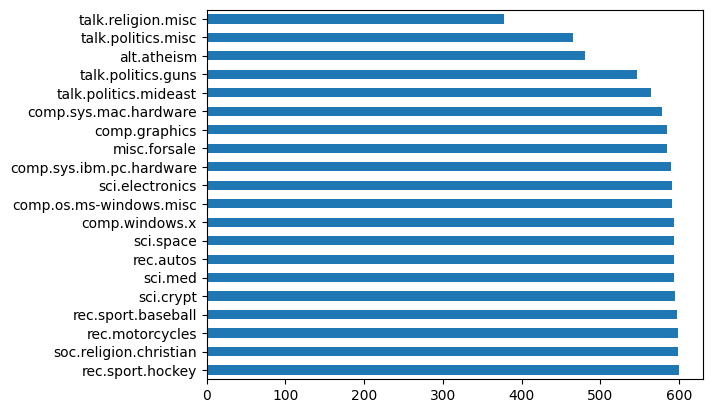

In [6]:
pd.Series(train_data.target).map(lambda x: train_data.target_names[x]).value_counts().plot(kind='barh')

In [21]:
def plot_confusion_matrix(y_true, y_pred, classes,
                          normalize=False,
                          title=None,
                          cmap=plt.cm.Blues):

    if not title:
        if normalize:
            title = 'Normalized confusion matrix'
        else:
            title = 'Confusion matrix, without normalization'

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, ax = plt.subplots(figsize=(18, 14))

    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    ax.grid(False)

    ax.set(
        xticks=np.arange(cm.shape[1]),
        yticks=np.arange(cm.shape[0]),
        xticklabels=classes,
        yticklabels=classes,
        title=title,
        ylabel='True label',
        xlabel='Predicted label'
    )


    plt.setp(ax.get_xticklabels(), rotation=90, ha="right", fontsize=10)
    plt.setp(ax.get_yticklabels(), fontsize=10)

    # Annotate
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i,
                    format(cm[i, j], fmt),
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="white" if cm[i, j] > thresh else "black")

    fig.tight_layout()
    return ax

# 2. Text Preprocessing
Here are some preprocessing steps to consider:

- Removing noise: html markups, urls, non-ascii symbols, trailing whitespace etc.
- Removing punctuation
- Normalizing emoticons
- Negation handling
- Tokenization: split text into word tokens
- Stopword removal
- Stemming or lemmatization

However, most of these steps did not improve our classification results. Since our data was mostly taken from written dialogs it was almost ready to use.

In [8]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english')) - {'not', 'no'}

def text_preprocessing(text):
    # 1. Clean
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = ' '.join(text.split())

    # 2. Tokenize
    tokens = word_tokenize(text)

    # 3. Stop words removal
    tokens = [t for t in tokens if t not in stop_words]

    # 4. Lemmatization (verb-aware)
    tokens = [lemmatizer.lemmatize(t, pos='v') for t in tokens]

    # 5. Remove short words
    tokens = [t for t in tokens if len(t) > 2]

    return tokens

raw = "The users are RUNNING apps!! Check https://x.com"
result = text_preprocessing(raw)
print(result)

['users', 'run', 'apps', 'check']


# 3. Text Representation
Vectorizing text using Term Frequency technique (Term Frequency(TF) — Inverse Dense Frequency(IDF))

- Tekenize with our text_preprocessing
- Find it’s TF = (Number of repetitions of word in a document) / (# of words in a document)
- IDF = log(# of documents / # of documents containing the word)

In [9]:

# TFIDF, unigrams and bigrams
vector = TfidfVectorizer(
    tokenizer=text_preprocessing,
    ngram_range=(1,2),
    sublinear_tf=True,
    norm='l2',
    max_features=100000,
    min_df=5,
    max_df=0.8
)

# fit on our complete corpus
vector.fit(X_train)

# transform testing and training datasets to vectors
X_train_vect = vector.transform(X_train)
X_test_vect = vector.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [10]:

print(X_test_vect.shape)
print(X_test_vect[0])

(7532, 59823)
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 58 stored elements and shape (1, 59823)>
  Coords	Values
  (0, 1317)	0.05540929097506177
  (0, 4923)	0.07607942376179284
  (0, 4965)	0.19062131844445934
  (0, 5733)	0.14549519350288984
  (0, 6296)	0.1371112195359621
  (0, 6297)	0.16063528026404789
  (0, 6518)	0.0783162954900377
  (0, 9761)	0.114110666707465
  (0, 10460)	0.05777204714482923
  (0, 10583)	0.13094650263824373
  (0, 11212)	0.11893994132379378
  (0, 11215)	0.17709512855244716
  (0, 12179)	0.11560723482380283
  (0, 12820)	0.12285926016405369
  (0, 14257)	0.09900761754213834
  (0, 16834)	0.07755329998716831
  (0, 17030)	0.10811714219671217
  (0, 18872)	0.3227499478788558
  (0, 19206)	0.04417746140093202
  (0, 21506)	0.1245662403177155
  (0, 23630)	0.08687264232122992
  (0, 26298)	0.046500628835270966
  (0, 26319)	0.18420156511923114
  (0, 27507)	0.08375533993174254
  (0, 28240)	0.16063528026404789
  :	:
  (0, 33677)	0.11639492052126948
  (0, 33680)	0.1

# 4. Classifiers

## Logistic Regression

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 83.78%

F1 Score: 83.78

COnfusion Matrix:
 [[226   3   0   0   0   0   2   1   0   2   1   1   3   9   5  41   0   5
    0  20]
 [  3 297  11   9  12  26   5   0   0   2   0   2  13   0   4   2   1   0
    2   0]
 [  0  24 294  24  11  12   1   1   1   4   1   2   3   1   6   2   1   0
    5   1]
 [  1  17  26 288  20   4   8   0   0   1   0   1  26   0   0   0   0   0
    0   0]
 [  0   4   6  22 327   0  12   0   0   2   0   0  11   0   1   0   0   0
    0   0]
 [  0  45  30   6   2 299   4   1   0   1   0   0   3   0   3   0   0   0
    1   0]
 [  0   2   1  15   6   0 345   4   1   1   1   1  10   2   1   0   0   0
    0   0]
 [  0   2   0   2   0   1  12 356   7   2   0   0  10   2   0   0   1   0
    1   0]
 [  0   0   0   1   0   0   4   7 375   1   0   0   5   2   0   1   1   0
    1   0]
 [  0   1   0   0   0   1   5   0   0 376  10   0   1   1   0   1   0   0
    1   0]
 [  0   1   0   0   0   2   1   0   0   8 385   0   0   0   0   2   0   0
    0   0]
 [  1   9  

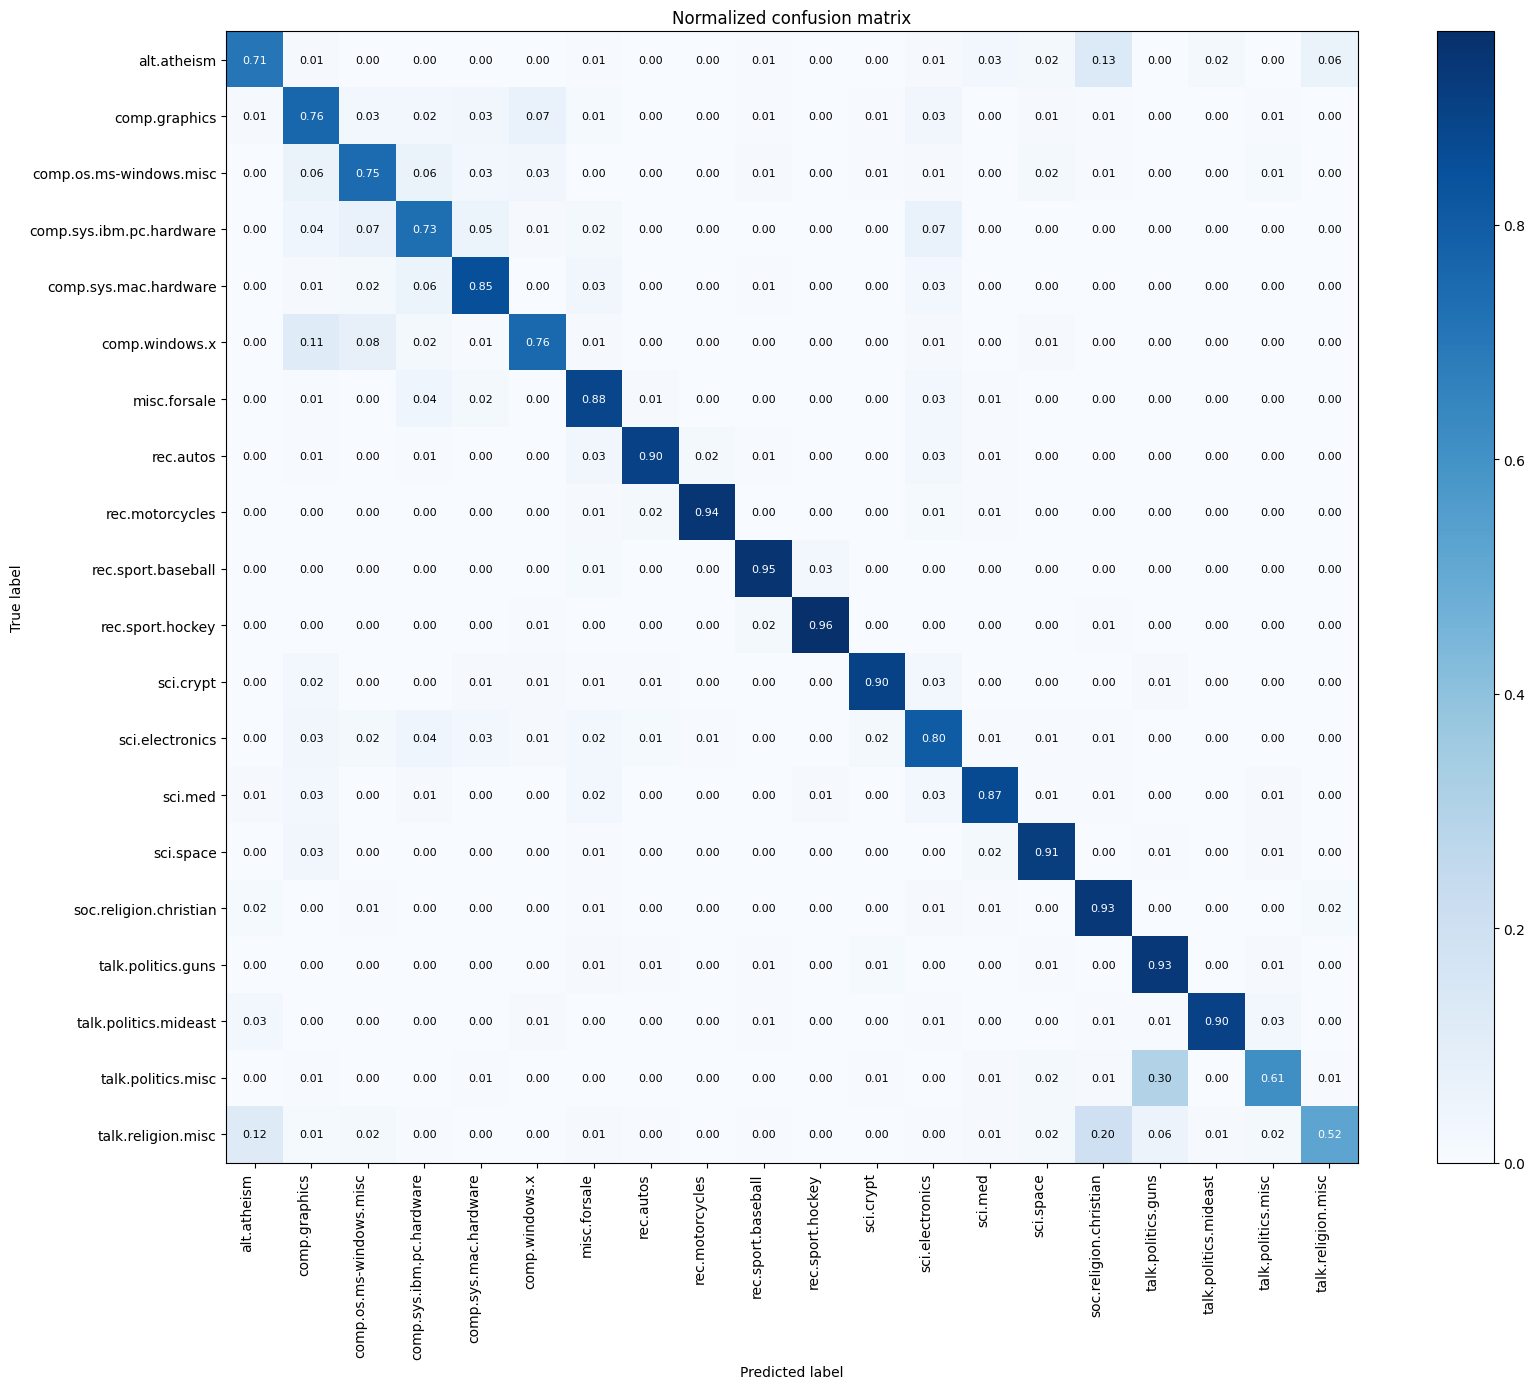

In [23]:
log = LogisticRegression(solver='lbfgs', multi_class='auto', max_iter=200)
log.fit(X_train_vect, y_train)

ylog_pred = log.predict(X_test_vect)

print("Accuracy: {:.2f}%".format(accuracy_score(y_test, ylog_pred) * 100))
print("\nF1 Score: {:.2f}".format(f1_score(y_test, ylog_pred, average='micro') * 100))
print("\nCOnfusion Matrix:\n", confusion_matrix(y_test, ylog_pred))

plot_confusion_matrix(y_test, ylog_pred, classes=train_data.target_names, normalize=True, title='Normalized confusion matrix')
plt.show()

## Linear Support Vector

Accuracy: 85.34%

F1 Score: 85.34

COnfusion Matrix:
 [[241   2   0   0   0   0   1   0   1   0   0   1   2   7   5  22   0   2
    1  34]
 [  2 297  13   9   8  21   4   0   0   3   1   7  13   0   5   2   0   1
    2   1]
 [  0  17 294  29  10  12   2   0   1   4   1   2   4   2   6   1   0   0
    5   4]
 [  1  17  26 287  25   2  10   0   0   1   0   2  18   1   1   0   1   0
    0   0]
 [  0   4   4  15 334   1  13   2   0   2   0   0   7   1   0   1   0   1
    0   0]
 [  0  33  28   4   5 308   3   1   0   1   0   0   5   0   2   0   2   0
    2   1]
 [  0   1   0  13   7   1 352   2   2   0   2   1   6   2   1   0   0   0
    0   0]
 [  0   2   0   5   0   1  12 354   8   1   0   0   9   2   0   0   0   0
    2   0]
 [  0   0   0   0   0   0   4   6 378   0   1   0   3   2   0   2   1   0
    1   0]
 [  0   1   0   0   2   1   4   0   0 381   4   0   1   1   0   1   0   0
    1   0]
 [  0   0   0   1   0   2   0   0   0   7 386   0   1   0   0   2   0   0
    0   0]
 [  1   3  

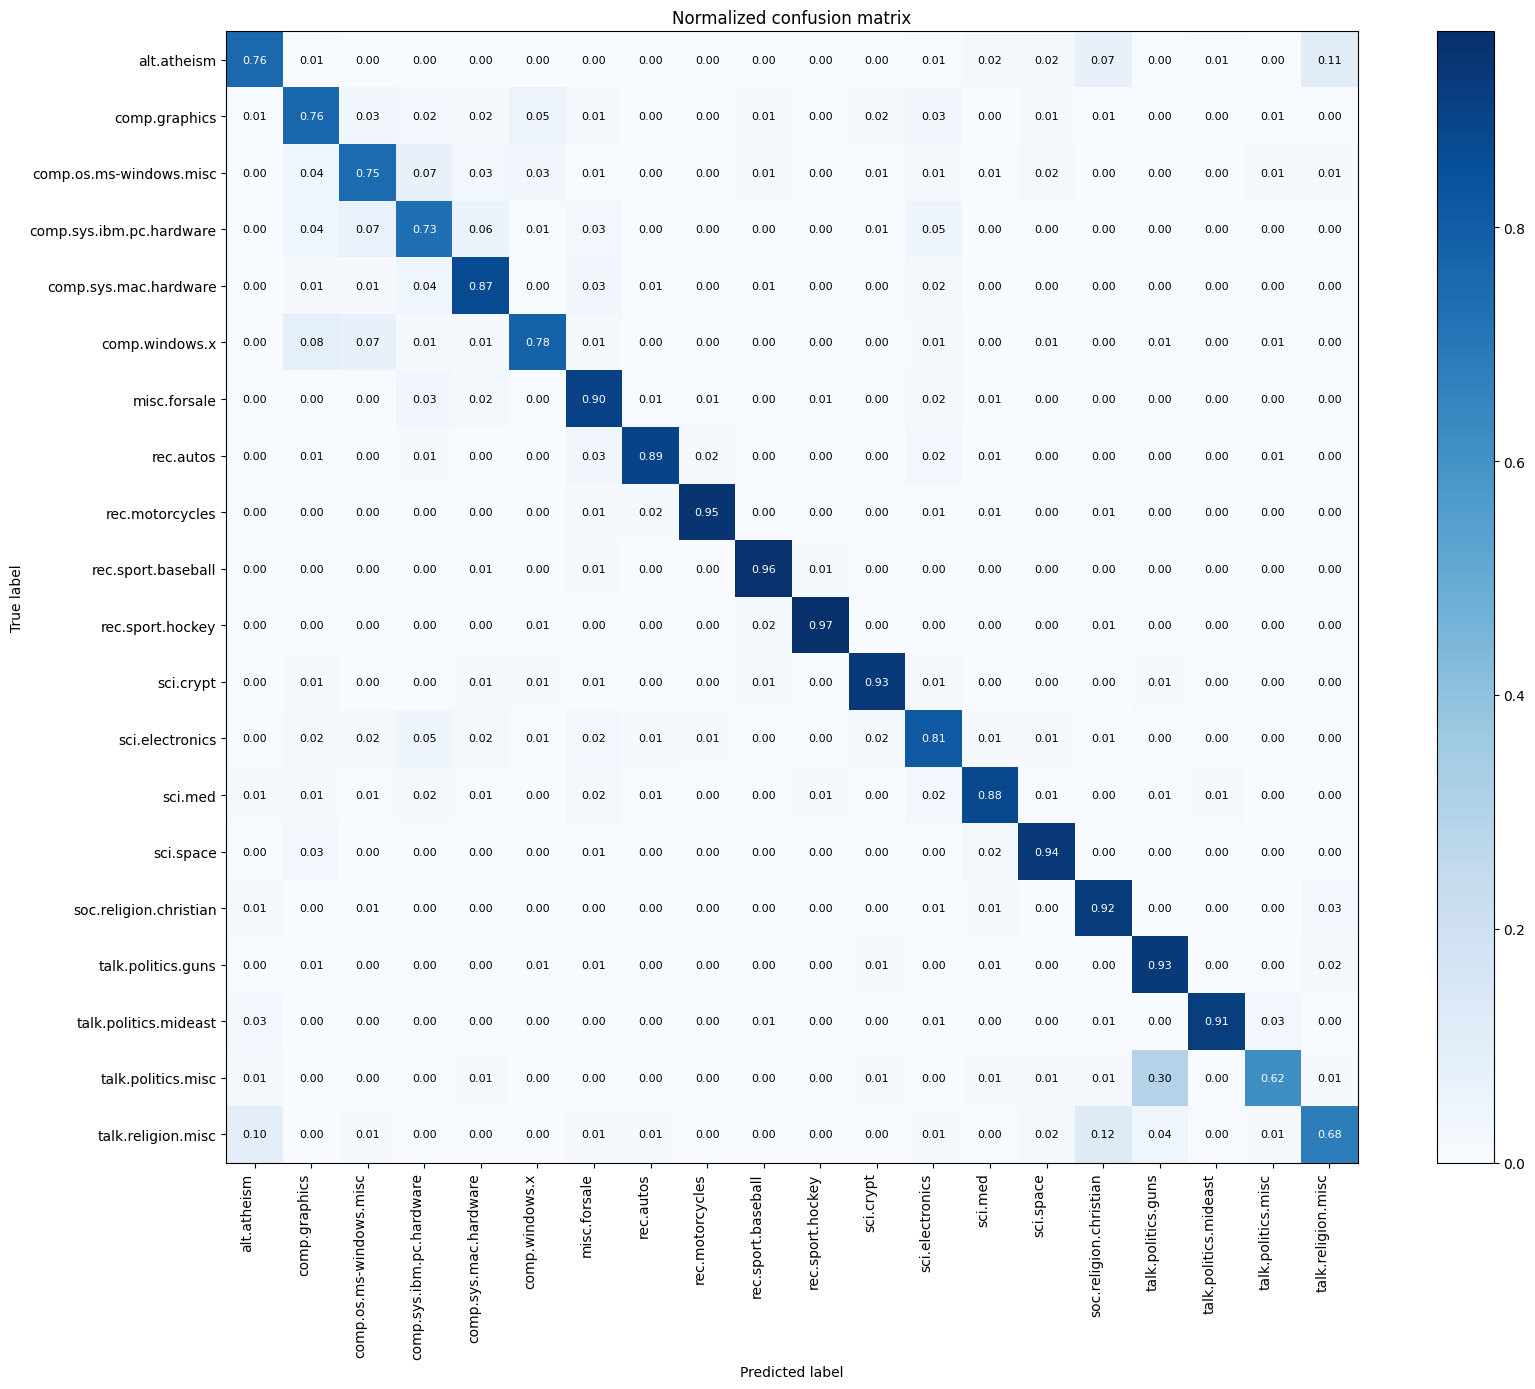

In [22]:
svc = LinearSVC(tol=1e-05)
svc.fit(X_train_vect, y_train)

ysvm_pred = svc.predict(X_test_vect)

print("Accuracy: {:.2f}%".format(accuracy_score(y_test, ysvm_pred) * 100))
print("\nF1 Score: {:.2f}".format(f1_score(y_test, ysvm_pred, average='micro') * 100))
print("\nCOnfusion Matrix:\n", confusion_matrix(y_test, ysvm_pred))

plot_confusion_matrix(y_test, ysvm_pred, classes=train_data.target_names, normalize=True, title='Normalized confusion matrix')
plt.show()

## Naive Bayes

Accuracy: 82.01%

F1 Score: 82.01

COnfusion Matrix:
 [[202   1   0   1   0   0   0   1   0   1   1   4   1   8   4  76   2  14
    0   3]
 [  1 270  13  19  13  35   4   1   0   1   1  11   8   1   5   5   1   0
    0   0]
 [  0  22 272  38   8  15   3   1   0   5   1  12   1   1   7   7   1   0
    0   0]
 [  1  10  15 306  16   6   8   3   0   0   1   3  19   0   4   0   0   0
    0   0]
 [  0   3   8  24 316   1   9   2   0   3   2   2   8   1   5   0   0   0
    1   0]
 [  1  29  11   9   1 325   2   1   1   0   0   7   1   0   5   1   0   1
    0   0]
 [  0   5   2  22   5   0 332   6   4   0   3   0   5   5   1   0   0   0
    0   0]
 [  0   1   0   4   0   1   7 361   6   3   2   0   5   3   1   0   1   0
    1   0]
 [  0   0   0   1   1   0   4  10 374   1   0   1   1   2   0   2   1   0
    0   0]
 [  0   2   0   0   1   1   4   0   0 367  18   0   0   1   0   2   0   1
    0   0]
 [  0   0   0   0   0   1   1   0   0   5 389   0   1   0   0   2   0   0
    0   0]
 [  0   4  

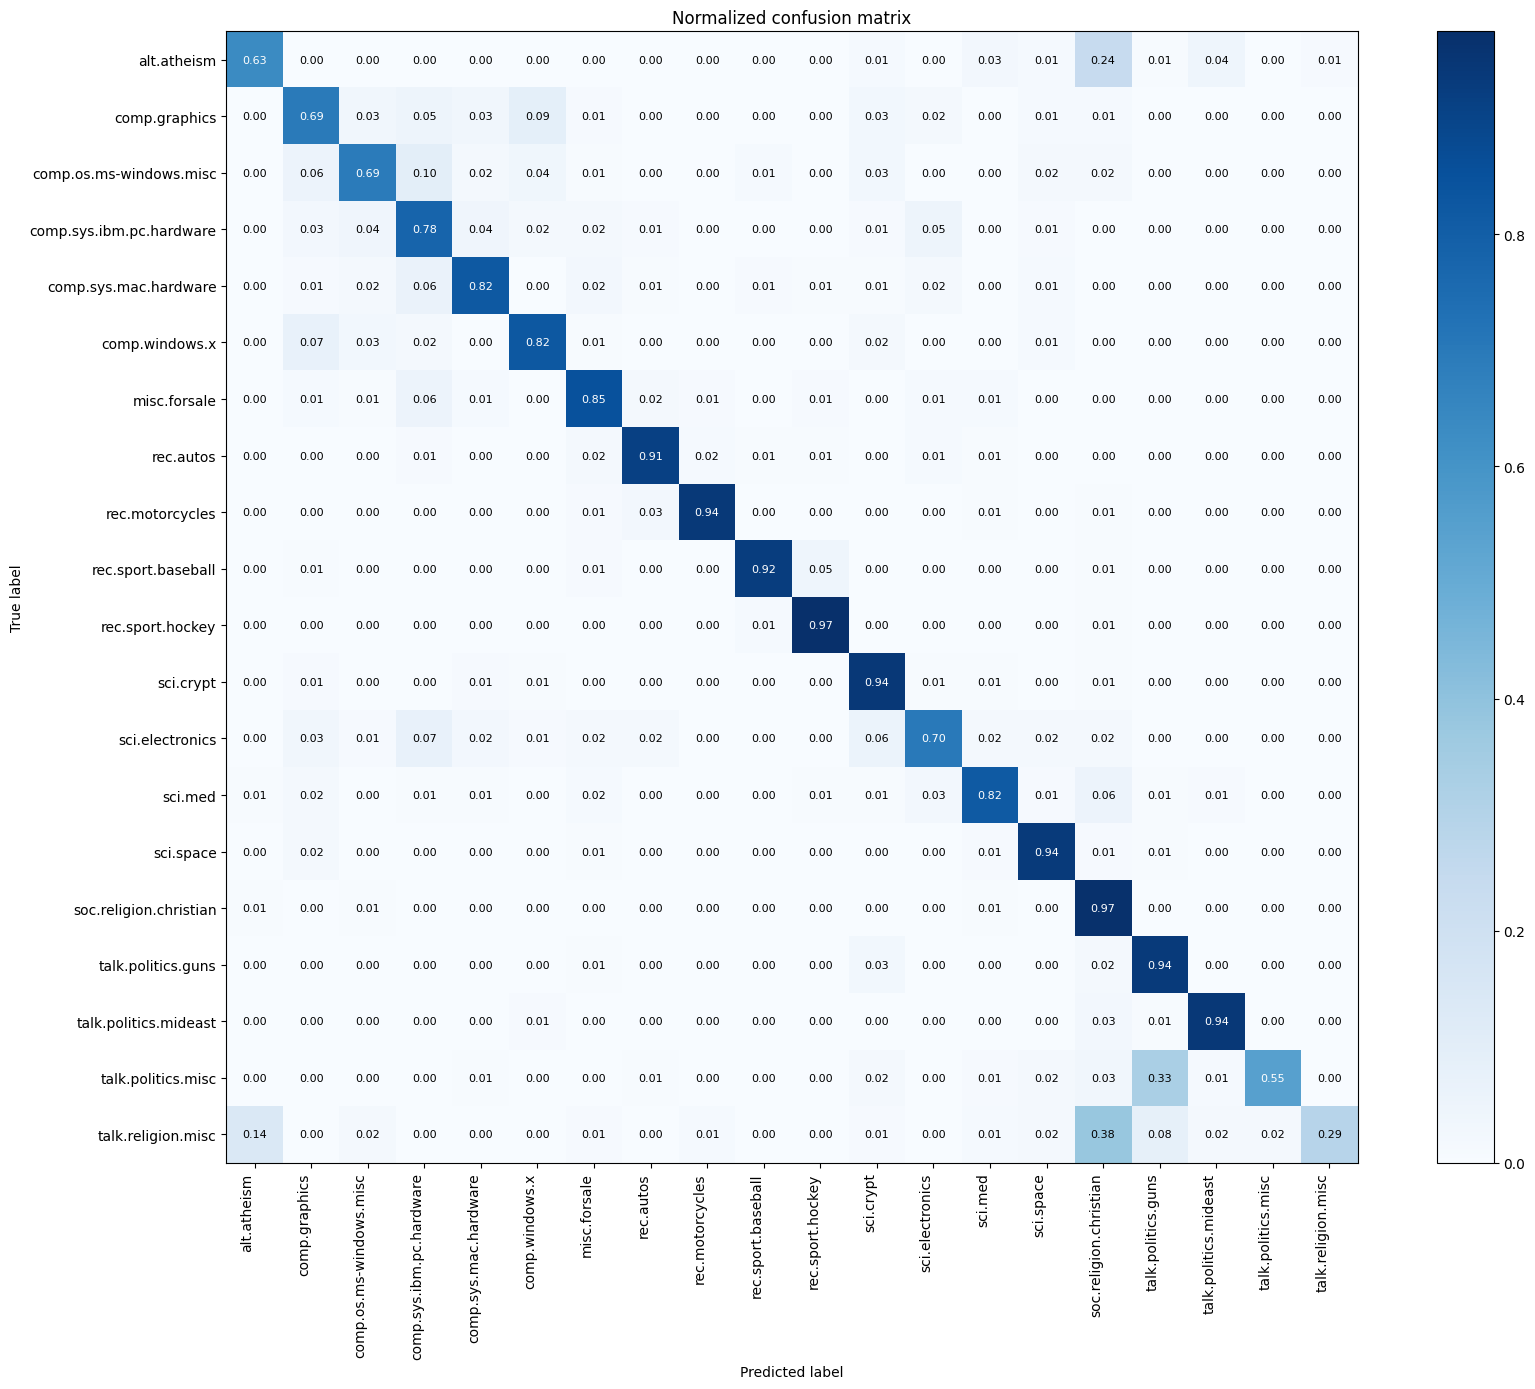

In [26]:
nb = MultinomialNB()

nb.fit(X_train_vect, y_train)

ynb_pred = nb.predict(X_test_vect)

print("Accuracy: {:.2f}%".format(accuracy_score(y_test, ynb_pred) * 100))
print("\nF1 Score: {:.2f}".format(f1_score(y_test, ynb_pred, average='micro') * 100))
print("\nCOnfusion Matrix:\n", confusion_matrix(y_test, ynb_pred))

# Plot normalized confusion matrix
plot_confusion_matrix(y_test, ynb_pred, classes=train_data.target_names, normalize=True, title='Normalized confusion matrix')
plt.show()